# Passo 1 — Conhecer a base de qualidade de vinhos

**Projeto da disciplina de Aprendizado de Máquina**

Neste notebook, vamos definir a pergunta do grupo, carregar os dados e investigar como a base está organizada. Ao terminar, teremos informações para começar as seções **1. Objetivo da modelagem** e **2. Dados utilizados** do relatório.

O passo 1 termina na auditoria. A limpeza, a separação entre treino e teste e o primeiro modelo serão feitos no passo 2 do [guia](passo_a_passo.md).

**Como usar:** execute as células em ordem com `Shift + Enter`. Para escrever nas respostas finais, dê dois cliques na célula de texto. As tabelas e os gráficos são gerados com os arquivos efetivamente carregados.


## 1.1 — Definir a pergunta

> Queremos prever a **nota de qualidade de uma amostra de vinho**, a partir de suas **11 medidas físico-químicas e do tipo do vinho**, e o modelo devolve **um número**.

- **Unidade de observação:** uma amostra de vinho.
- **Alvo:** `quality`, a nota sensorial.
- **Tarefa:** regressão.
- **Exemplo de saída futura:** 6,3 pontos.
- **Uso a discutir:** priorizar amostras para degustação humana.

A nota é ordenada. Ao usar regressão, assumimos que diferenças entre notas podem ser comparadas numericamente. A escala documentada vai de 0 a 10; vamos verificar quais notas realmente aparecem na amostra.

**Ainda não há previsão neste notebook:** primeiro precisamos conhecer os dados.


## 1.2 — Importar as ferramentas

Usaremos `pandas` para as tabelas, `numpy` para conferir os números e `matplotlib` para visualizar as notas. Se houver erro de importação, selecione o kernel `.venv` do repositório ou instale as dependências de `requirements.txt` no seu ambiente.


In [1]:
from io import BytesIO
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Ambiente pronto. pandas:", pd.__version__)


Ambiente pronto. pandas: 3.0.5


## 1.3 — Carregar os dois arquivos

O enunciado fornece um CSV de vinhos tintos e outro de brancos. Eles usam **ponto e vírgula** como separador, por isso precisamos de `sep=";"`.

Na primeira execução, a próxima célula baixa os arquivos e guarda cópias em `projeto/dados/`. Depois, ela usa essas cópias. Execute o notebook com a pasta de trabalho na raiz do repositório ou na pasta `projeto`.

A origem do conjunto é o [UCI Wine Quality](https://doi.org/10.24432/C56S3T). Os endereços abaixo são os espelhos indicados no enunciado.


In [2]:
URLS = {
    "red": "https://raw.githubusercontent.com/zygmuntz/wine-quality/master/winequality/winequality-red.csv",
    "white": "https://raw.githubusercontent.com/zygmuntz/wine-quality/master/winequality/winequality-white.csv",
}

COLUNAS_ORIGINAIS = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide",
    "density", "pH", "sulphates", "alcohol", "quality",
]

pasta_atual = Path.cwd()
PASTA_PROJETO = pasta_atual if pasta_atual.name == "projeto" else pasta_atual / "projeto"
PASTA_DADOS = PASTA_PROJETO / "dados"
PASTA_DADOS.mkdir(parents=True, exist_ok=True)


def carregar_vinhos(tipo):
    caminho = PASTA_DADOS / f"winequality-{tipo}.csv"
    conteudo_baixado = None
    if caminho.exists():
        tabela = pd.read_csv(caminho, sep=";")
        origem = "cópia local"
    else:
        try:
            requisicao = Request(URLS[tipo], headers={"User-Agent": "Projeto-Qualidade-Vinhos"})
            with urlopen(requisicao, timeout=30) as resposta:
                conteudo_baixado = resposta.read()
            tabela = pd.read_csv(BytesIO(conteudo_baixado), sep=";")
        except Exception as erro:
            raise RuntimeError(
                f"Não foi possível baixar {caminho.name}. Confira a internet ou "
                f"baixe o CSV do endereço acima e coloque-o em {PASTA_DADOS}."
            ) from erro
        origem = "download público"

    if tabela.columns.tolist() != COLUNAS_ORIGINAIS:
        raise ValueError(
            f"Colunas inesperadas em {caminho.name}. Confira o arquivo e o separador ';'."
        )
    if tabela.empty:
        raise ValueError(f"O arquivo {caminho.name} está vazio.")

    # Só guardamos o download depois de conferir sua estrutura.
    if conteudo_baixado is not None:
        caminho.write_bytes(conteudo_baixado)

    print(f"{caminho.name}: {len(tabela):,} linhas, {tabela.shape[1]} colunas ({origem}).")
    return tabela


tintos = carregar_vinhos("red")
brancos = carregar_vinhos("white")


winequality-red.csv: 1,599 linhas, 12 colunas (download público).


winequality-white.csv: 4,898 linhas, 12 colunas (download público).


## 1.4 — Identificar o tipo e juntar as tabelas

Os arquivos originais não têm uma coluna com o tipo. Acrescentamos `wine_type` para guardar essa informação antes da união: `red` significa tinto e `white` significa branco.

Vamos usar o nome **dados_brutos** para lembrar que as repetições e os valores originais ainda estão preservados. `assign()` cria as versões com a nova coluna sem alterar as tabelas originais.


In [3]:
dados_brutos = pd.concat(
    [
        tintos.assign(wine_type="red"),
        brancos.assign(wine_type="white"),
    ],
    ignore_index=True,
)

resumo_arquivos = pd.DataFrame({
    "Tabela": ["Tintos (original)", "Brancos (original)", "Base combinada"],
    "Linhas": [len(tintos), len(brancos), len(dados_brutos)],
    "Colunas": [tintos.shape[1], brancos.shape[1], dados_brutos.shape[1]],
})
display(resumo_arquivos)
display(dados_brutos.head())

print("Tipos de vinho:", dados_brutos["wine_type"].unique().tolist())
print("O esperado nos arquivos do enunciado é 6.497 linhas e 13 colunas após acrescentar wine_type.")


,Tabela,Linhas,Colunas
0,Tintos (original),1599,12
1,Brancos (original),4898,12
2,Base combinada,6497,13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Tipos de vinho: ['red', 'white']
O esperado nos arquivos do enunciado é 6.497 linhas e 13 colunas após acrescentar wine_type.


## 1.5 — Entender as colunas

| Coluna | Significado | Papel |
| --- | --- | --- |
| `fixed acidity` | Acidez fixa | Entrada |
| `volatile acidity` | Acidez volátil | Entrada |
| `citric acid` | Ácido cítrico | Entrada |
| `residual sugar` | Açúcar residual | Entrada |
| `chlorides` | Cloretos | Entrada |
| `free sulfur dioxide` | Dióxido de enxofre livre | Entrada |
| `total sulfur dioxide` | Dióxido de enxofre total | Entrada |
| `density` | Densidade | Entrada |
| `pH` | pH | Entrada |
| `sulphates` | Sulfatos | Entrada |
| `alcohol` | Teor alcoólico | Entrada |
| `quality` | Nota de qualidade | **Alvo** |
| `wine_type` | Tinto ou branco | Entrada criada a partir do arquivo |

O alvo é numérico. `wine_type` é categórico e precisará de codificação quando criarmos o modelo.

A auditoria abaixo procura células ausentes e textos vazios. Em seguida, confere se as 12 colunas originais podem ser tratadas como números.


In [4]:
textos_vazios = dados_brutos.apply(
    lambda coluna: coluna.astype("string").str.strip().eq("").sum()
)
auditoria = pd.DataFrame({
    "tipo": dados_brutos.dtypes.astype(str),
    "ausentes": dados_brutos.isna().sum(),
    "textos_vazios": textos_vazios,
    "valores_distintos": dados_brutos.nunique(),
})
display(auditoria)

numericos = dados_brutos[COLUNAS_ORIGINAIS].apply(pd.to_numeric, errors="coerce")
nao_numericos = (numericos.isna() & dados_brutos[COLUNAS_ORIGINAIS].notna()).sum()
nao_finitos = int(np.isinf(numericos.to_numpy(dtype=float)).sum())

print("Células ausentes:", int(dados_brutos.isna().sum().sum()))
print("Células com texto vazio:", int(textos_vazios.sum()))
print("Valores não numéricos nas colunas originais:", int(nao_numericos.sum()))
print("Valores infinitos:", nao_finitos)

if nao_numericos.sum() or nao_finitos:
    raise ValueError("Há valores inválidos. Investigue-os antes de continuar.")


,tipo,ausentes,textos_vazios,valores_distintos
fixed acidity,float64,0,0,106
volatile acidity,float64,0,0,187
citric acid,float64,0,0,89
residual sugar,float64,0,0,316
chlorides,float64,0,0,214
free sulfur dioxide,float64,0,0,135
total sulfur dioxide,float64,0,0,276
density,float64,0,0,998
pH,float64,0,0,108
sulphates,float64,0,0,111


Células ausentes: 0
Células com texto vazio: 0
Valores não numéricos nas colunas originais: 0
Valores infinitos: 0


**Como interpretar:** não encontrar valores ausentes não significa que a base está perfeita. Ainda precisamos examinar repetições e a distribuição das medidas.

Zero também não significa automaticamente ausência. Não troque todos os zeros por valores ausentes: confirme o significado de cada variável antes de tratar seus valores.


## 1.6 — Investigar linhas repetidas

`duplicated()` marca as repetições **depois da primeira ocorrência**. Vamos contar duplicatas completas, incluindo o tipo do vinho e a nota.

Também verificaremos se há **entradas iguais com notas diferentes**. São duas situações distintas, com consequências para a futura separação entre treino e teste.


In [5]:
duplicatas_completas = int(dados_brutos.duplicated().sum())

duplicatas_por_tipo = (
    dados_brutos.groupby("wine_type")
    .agg(
        linhas=("quality", "size"),
    )
)
duplicatas_por_tipo["repeticoes_completas"] = [
    int(dados_brutos.loc[dados_brutos["wine_type"].eq(tipo)].duplicated().sum())
    for tipo in duplicatas_por_tipo.index
]
duplicatas_por_tipo["linhas_apos_remocao"] = (
    duplicatas_por_tipo["linhas"] - duplicatas_por_tipo["repeticoes_completas"]
)
display(duplicatas_por_tipo)

print("Repetições completas além da primeira ocorrência:", duplicatas_completas)
print("Linhas que restariam se as removêssemos:", len(dados_brutos) - duplicatas_completas)
print("Exemplos de linhas repetidas (incluindo sua primeira ocorrência):")
display(dados_brutos.loc[dados_brutos.duplicated(keep=False)].head(8))


,linhas,repeticoes_completas,linhas_apos_remocao
wine_type,,,
red,1599,240,1359
white,4898,937,3961


Repetições completas além da primeira ocorrência: 1177
Linhas que restariam se as removêssemos: 5320
Exemplos de linhas repetidas (incluindo sua primeira ocorrência):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red
22,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,red
27,7.9,0.43,0.21,1.6,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,red
39,7.3,0.45,0.36,5.9,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,red
40,7.3,0.45,0.36,5.9,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,red


In [6]:
COLUNAS_ENTRADA = [coluna for coluna in dados_brutos.columns if coluna != "quality"]

notas_por_perfil = (
    dados_brutos.groupby(COLUNAS_ENTRADA, dropna=False)["quality"]
    .nunique()
)
perfis_com_notas_diferentes = int(notas_por_perfil.gt(1).sum())

print("Perfis de entrada idênticos com mais de uma nota:", perfis_com_notas_diferentes)
print("A base continua com", len(dados_brutos), "linhas: nada foi descartado nesta etapa.")


Perfis de entrada idênticos com mais de uma nota: 0
A base continua com 6497 linhas: nada foi descartado nesta etapa.


**Decisão a registrar para o passo 2:** uma opção é remover duplicatas completas antes de dividir os dados. Isso reduz repetições que poderiam facilitar artificialmente o teste, mas não prova que cada repetição é um erro: faltam identificadores para confirmar a origem.

Se houver entradas iguais com notas diferentes, remover apenas duplicatas completas não resolve essa situação. Será necessário discutir a manutenção desses casos e uma divisão por grupos, se o objetivo for manter perfis idênticos na mesma partição.

**Pergunta para o grupo:** o que poderia acontecer com a avaliação se uma cópia da mesma amostra estivesse no treino e outra no teste?


## 1.7 — Ler as estatísticas descritivas

`describe()` informa quantidade, média, desvio-padrão, mínimo, quartis e máximo. Compare cada coluna com ela mesma: as medidas têm escalas diferentes.

Uma média não conta tudo. Um máximo distante do terceiro quartil é um motivo para investigar, não uma ordem para excluir a linha.


In [7]:
display(dados_brutos[COLUNAS_ORIGINAIS].describe().T.round(3))

resumo_por_tipo = (
    dados_brutos.groupby("wine_type")[
        ["alcohol", "volatile acidity", "residual sugar", "quality"]
    ]
    .agg(["mean", "median"])
    .round(3)
)
display(resumo_por_tipo)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000


alcohol        volatile acidity        residual sugar        quality       
             mean median             mean median           mean median    mean median
wine_type                                                                            
red        10.423   10.2            0.528   0.52          2.539    2.2   5.636    6.0
white      10.514   10.4            0.278   0.26          6.391    5.2   5.878    6.0

## 1.8 — Ver como as notas estão distribuídas

`value_counts()` mostra quantos exemplos existem de cada nota. Vamos calcular também as porcentagens.

Mesmo usando regressão, a distribuição importa: um modelo treinado com muitos exemplos de notas intermediárias pode ter mais dificuldade nos extremos.


In [8]:
contagem_notas = dados_brutos["quality"].value_counts().sort_index()
distribuicao_notas = pd.DataFrame({
    "quantidade": contagem_notas,
    "percentual": (100 * contagem_notas / len(dados_brutos)).round(2),
})
distribuicao_notas.index.name = "quality"
display(distribuicao_notas)

proporcao_5_6 = dados_brutos["quality"].isin([5, 6]).mean()
print("Menor nota observada:", dados_brutos["quality"].min())
print("Maior nota observada:", dados_brutos["quality"].max())
print(f"Percentual de notas 5 ou 6: {100 * proporcao_5_6:.1f}%")

notas_fora_da_escala = int((~dados_brutos["quality"].between(0, 10)).sum())
print("Notas fora da escala documentada de 0 a 10:", notas_fora_da_escala)


,quantidade,percentual
quality,,
3,30,0.46
4,216,3.32
5,2138,32.91
6,2836,43.65
7,1079,16.61
8,193,2.97
9,5,0.08


Menor nota observada: 3
Maior nota observada: 9
Percentual de notas 5 ou 6: 76.6%
Notas fora da escala documentada de 0 a 10: 0


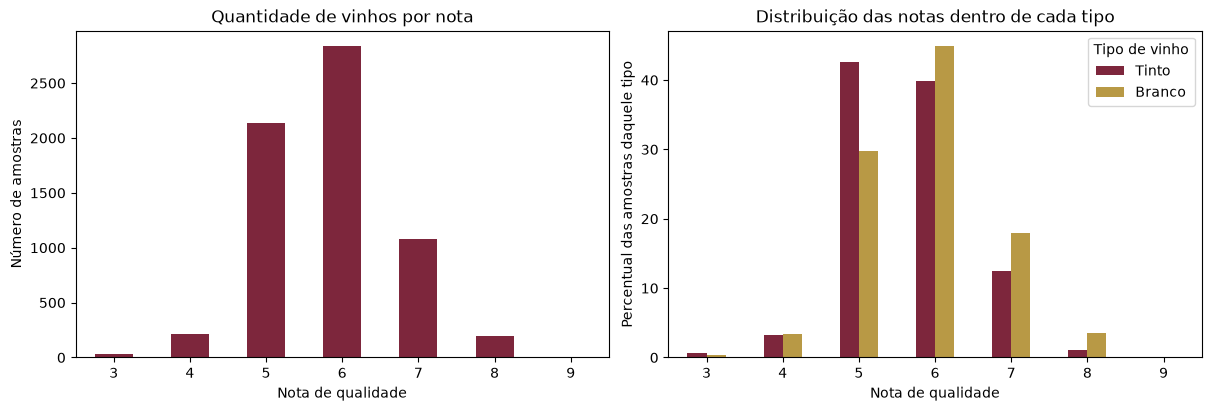

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

contagem_notas.plot.bar(ax=eixos[0], color="#7D263C", rot=0)
eixos[0].set_title("Quantidade de vinhos por nota")
eixos[0].set_xlabel("Nota de qualidade")
eixos[0].set_ylabel("Número de amostras")

notas_por_tipo = pd.crosstab(
    dados_brutos["quality"],
    dados_brutos["wine_type"],
    normalize="columns",
).mul(100)
notas_por_tipo = notas_por_tipo.reindex(columns=["red", "white"])
notas_por_tipo.columns = ["Tinto", "Branco"]
notas_por_tipo.plot.bar(
    ax=eixos[1], color=["#7D263C", "#B89945"], rot=0
)
eixos[1].set_title("Distribuição das notas dentro de cada tipo")
eixos[1].set_xlabel("Nota de qualidade")
eixos[1].set_ylabel("Percentual das amostras daquele tipo")
eixos[1].legend(title="Tipo de vinho")

plt.show()


**Leia o gráfico:** o primeiro painel apresenta quantidades totais. O segundo usa percentuais dentro de cada tipo, pois a quantidade de brancos é maior que a de tintos.

Não interprete a ausência de notas 0, 1, 2 ou 10 como falha na leitura. A escala possível e as notas realmente observadas são coisas diferentes.


## 1.9 — Separar as entradas do alvo

Vamos criar `X` e `y` apenas para entender os papéis das colunas.

- `X`: informações disponíveis para prever a nota.
- `y`: nota conhecida nos exemplos históricos, usada para ensinar e avaliar o modelo.

**Por que retirar `quality` de `X`?** Usar a própria resposta como entrada seria vazamento de informação. Um resultado assim não serviria para prever uma nota ainda desconhecida.

Estas tabelas ainda são brutas. No passo 2, vamos recriá-las depois da decisão de limpeza.


In [10]:
X_bruto = dados_brutos.drop(columns="quality").copy()
y_bruto = dados_brutos["quality"].copy()

assert "quality" not in X_bruto.columns
assert len(X_bruto) == len(y_bruto)

print("Formato das entradas X:", X_bruto.shape)
print("Formato do alvo y:", y_bruto.shape)
print("Entradas:", X_bruto.columns.tolist())
print("Alvo:", y_bruto.name)

display(X_bruto.head(3))
display(y_bruto.head(3).to_frame())


Formato das entradas X: (6497, 12)
Formato do alvo y: (6497,)
Entradas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']
Alvo: quality


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,red


,quality
0,5
1,5
2,5


## 1.10 — Registrar as descobertas

A tabela abaixo resume a auditoria. Use as saídas para preencher as respostas seguintes com suas palavras.


In [11]:
descobertas = pd.DataFrame([
    ["Pergunta", "Prever a nota de qualidade a partir das medidas e do tipo do vinho"],
    ["Tarefa", "Regressão"],
    ["Alvo", "quality"],
    ["Amostras originais", len(dados_brutos)],
    ["Entradas", X_bruto.shape[1]],
    ["Ausências", int(dados_brutos.isna().sum().sum())],
    ["Repetições completas além da primeira", duplicatas_completas],
    ["Perfis iguais com notas diferentes", perfis_com_notas_diferentes],
    ["Nota mínima observada", y_bruto.min()],
    ["Nota máxima observada", y_bruto.max()],
    ["Notas 5 ou 6", f"{100 * proporcao_5_6:.1f}%"],
    ["Linhas descartadas nesta etapa", 0],
], columns=["Item", "Resultado"])

display(descobertas)


,Item,Resultado
0,Pergunta,Prever a nota de qualidade a partir das medida...
1,Tarefa,Regressão
2,Alvo,quality
3,Amostras originais,6497
4,Entradas,12
5,Ausências,0
6,Repetições completas além da primeira,1177
7,Perfis iguais com notas diferentes,0
8,Nota mínima observada,3
9,Nota máxima observada,9


## Respostas do grupo

Edite esta célula e substitua os campos entre colchetes.

**1. Qual pergunta o grupo quer responder e qual será a saída do modelo?**  
[Escreva uma frase incluindo a nota, as entradas e a saída numérica.]

**2. De onde vieram os dados e o que representa uma linha?**  
[Informe a fonte, os dois arquivos e a unidade de observação.]

**3. Quantas linhas e colunas há antes e depois de adicionar o tipo do vinho?**  
[Use o resumo dos arquivos. Explique por que a base combinada tem 13 colunas.]

**4. Qual é o alvo? Quais são as entradas?**  
[Nomeie o alvo e explique por que ele não deve aparecer em X.]

**5. Existem valores ausentes ou duplicatas? Qual é a diferença entre essas situações?**  
[Informe o que a auditoria encontrou e proponha como investigar as repetições.]

**6. As notas estão distribuídas de forma equilibrada? Qual dificuldade isso pode criar?**  
[Comente a concentração em 5 e 6 e a raridade das notas extremas.]

**7. O que foi descartado neste passo? O que o grupo pretende decidir na próxima etapa?**  
[Declare o estado dos dados e justifique a decisão que ainda será tomada.]


## Checklist de conclusão

- [ ] Executei todas as células em ordem.
- [ ] Sei explicar a pergunta e por que a tarefa é regressão.
- [ ] Entendi o separador `;` e a criação de `wine_type`.
- [ ] Conferi ausências, duplicatas e estatísticas descritivas.
- [ ] Consigo interpretar o gráfico das notas.
- [ ] Sei por que `quality` não pode entrar nas variáveis preditoras.
- [ ] Preenchi as respostas do grupo e salvei o notebook.

**Próximo passo:** tratar os dados com justificativa, reservar o teste e ajustar a primeira regressão. Consulte o [passo 2 do guia](passo_a_passo.md#passo-2--preparar-os-dados-e-ajustar-a-primeira-regressão).

**Referências:** [UCI Wine Quality](https://doi.org/10.24432/C56S3T), os dois CSVs indicados na seção 1.3 e o enunciado `Projeto_disciplina.pdf`. Este notebook implementa somente a primeira etapa do roteiro; o projeto completo também exige treinamento, avaliação e relatório.
